# Career-ending injuries: logistic GLM

Predicts **P(injury ends the career)** — the claim that pays out the remaining contract. Code: `career.py`. Needs MySQL with soccer data + appearances loaded (`python build_db.py soccer data/football-datasets`).

## 1. Label and predictors

**Career-ending** = no later professional appearance in a season starting after the injury, and not back by the end of that season.
- Player's first such injury only; ≥2 full seasons of follow-up (injuries before July 2023).
- Excludes deaths and non-injuries (rest, fitness, suspension). Dropping to amateur football counts.
- **Predictors** known on injury day only: body region, injury type, age, position, injury history, recent and career games. Days missed is not used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import career
import severity as sev

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 80)

data = career.build_dataset()
train, test = career.split(data)      # by player
print(f"{len(data):,} injuries before {data.attrs['cutoff']:%Y-%m-%d}; "
      f"{data.career_ending.sum():,} career-ending ({data.career_ending.mean():.2%})")
print(f"train {len(train):,} / test {len(test):,}")

120,682 injuries before 2023-07-01; 504 career-ending (0.42%)
train 96,833 / test 23,849


### Label check
Expect serious diagnoses, mostly retired / without-club profiles, and long time out.

In [2]:
ended = data[data.career_ending == 1]
print("Most common descriptions:")
print(ended.injury_desc.value_counts().head(12).to_string())
status = np.select([ended.current_club.isin(["Retired", "Without Club", "Career break"]),
                    ended.current_club.isin(["Unknown", "---"]) | ended.current_club.isna()],
                   ["Retired / without club", "Unknown"], "At a club (mostly amateur)")
print("\nProfile status today:")
print(pd.Series(status).value_counts(normalize=True).round(3).to_string())
print(f"\nMedian days out: career-ending {ended.days_missed.median():.0f} vs. all others {data[data.career_ending == 0].days_missed.median():.0f}")

Most common descriptions:
injury_desc
Cruciate ligament tear       115
unknown injury                49
Knee injury                   43
Knee surgery                  21
Cartilage damage              18
Achilles tendon rupture       13
Knee problems                 13
heart problems                11
Cruciate ligament injury      11
Cruciate ligament surgery      9
Shoulder injury                9
Achilles tendon surgery        8

Profile status today:
Retired / without club        0.843
At a club (mostly amateur)    0.143
Unknown                       0.014

Median days out: career-ending 349 vs. all others 22


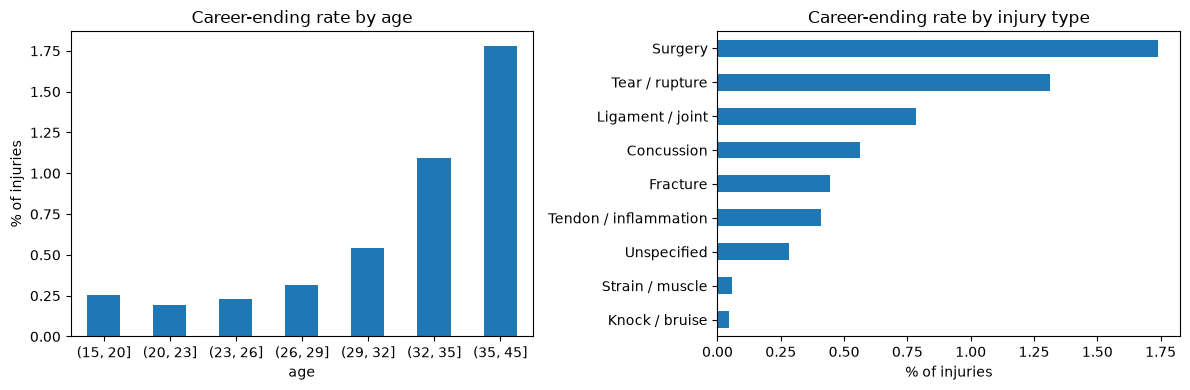

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
by_age = data.groupby(pd.cut(data.age, [15, 20, 23, 26, 29, 32, 35, 45]), observed=True).career_ending.mean() * 100
by_age.plot.bar(ax=ax[0], rot=0); ax[0].set(title="Career-ending rate by age", ylabel="% of injuries", xlabel="age")
by_type = data.groupby("nature", observed=True).career_ending.mean().sort_values() * 100
by_type.plot.barh(ax=ax[1]); ax[1].set(title="Career-ending rate by injury type", xlabel="% of injuries", ylabel="")
plt.tight_layout()

## 2. Models

| Model | |
|---|---|
| Base rate | Average rate for every injury (floor) |
| **Logistic GLM, main effects** | Binomial GLM, logit link → odds ratios |

Regions/types with <20 career-ending injuries in train are merged into **Other**.

## 3. ▶ GLM fit — logistic GLM (logit link)
Fits the base rate and the **Logistic GLM, main effects** (final model).

In [4]:
# ===================== GLM FIT =====================
# Logistic GLM: career_ending ~ Binomial, logit link (statsmodels sm.GLM)
# ===================================================
models = career.fit_all(train)   # career.default_models()

  fitting Base rate, no predictors ...


  fitting Logistic GLM, main effects ...


## 4. Held-out comparison
- **auc** — ranking (0.5 guess, 1 perfect) · **avg_precision** — vs. base rate ≈ 0.005
- **log_loss / brier** — probability quality, lower is better · **mean_pred** — should match actual rate
- **top10_capture** — share of career-ending injuries in the riskiest 10%

In [5]:
career.compare(models, test)

,auc,avg_precision,log_loss,brier,mean_pred,top10_capture
model,,,,,,
"Base rate, no predictors",0.50000,0.00457,0.02921,0.00455,0.00408,0.00000
"Logistic GLM, main effects",0.85745,0.04968,0.02439,0.00447,0.00404,0.55046
(actual),NaN,NaN,NaN,NaN,0.00457,NaN


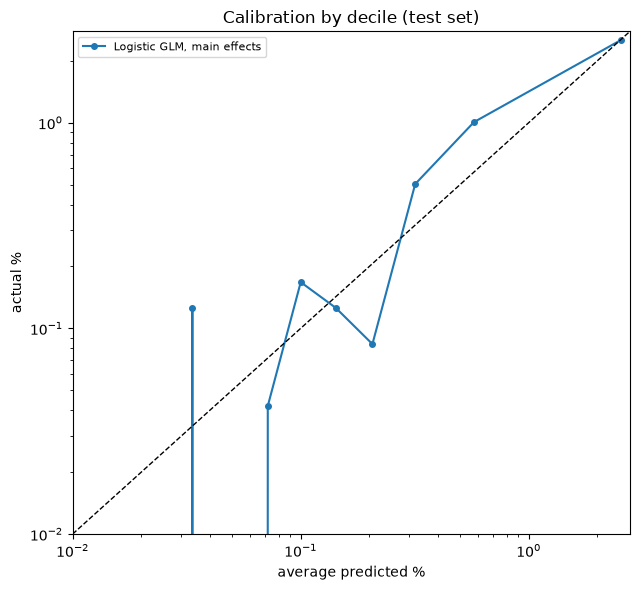

In [6]:
cal = career.calibration(models, test)
fig, ax = plt.subplots(figsize=(6.5, 6))
for name, g in cal.groupby("model", sort=False):
    ax.plot(g.pred * 100, g.actual * 100, "o-", ms=4, label=name)
lim = [0.01, max(cal.pred.max(), cal.actual.max()) * 110]
ax.plot(lim, lim, "k--", lw=1)
ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim, xlabel="average predicted %", ylabel="actual %",
       title="Calibration by decile (test set)")
ax.legend(fontsize=8)
plt.tight_layout()

## 5. Odds ratios (main-effects GLM)
Baseline: 26-year-old midfielder, unspecified hamstring injury, 2015. At these low rates OR ≈ relative risk.

In [7]:
career.odds_ratios(models["Logistic GLM, main effects"])

,odds_ratio,ci_low,ci_high,p_value
Intercept,0.0097,0.0030,0.0319,0.0000
region_g = Achilles,9.0642,3.0395,27.0312,0.0001
region_g = Knee,9.8255,3.5786,26.9773,0.0000
region_g = Other,1.6063,0.5843,4.4159,0.3584
region_g = Unknown,3.4556,1.2617,9.4643,0.0159
nature_g = Ligament / joint,1.4395,0.9504,2.1802,0.0855
nature_g = Other,0.7880,0.5438,1.1420,0.2082
nature_g = Surgery,3.1673,2.1239,4.7234,0.0000
nature_g = Tear / rupture,3.0457,2.3149,4.0070,0.0000
position_group = Attack,0.7811,0.5807,1.0506,0.1024


## Results (seed=42)

- **Label holds up:** 504 career-ending injuries (0.42% of 120,682); 84% now retired/without club; led by cruciate tears, other knee, Achilles; median 349 days out vs. 22.
- **Logistic GLM (held out):** AUC 0.857; riskiest 10% hold 55% of career-ending injuries; avg precision 0.050 (~11× base rate 0.0046).
- **Calibration:** mean prediction 0.40% vs. actual 0.46%; top decile predicted 2.53% vs. actual 2.52%.
- **Drivers:** knee ×9.8, Achilles ×9.1 vs. hamstring; surgery ×3.2, tear/rupture ×3.0; age +27%/yr at 26; defenders ×1.4; recent games ×0.53 per log unit; prior injuries ×0.73 per log unit; year +7%/yr (likely coverage).

**Expected cost** ≈ P(CE) × remaining contract + (1 − P(CE)) × E[days] × daily salary.